In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [4]:
df = pd.read_csv("questions.csv")

In [6]:
df.head()
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 404351 entries, 0 to 404350
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            404351 non-null  int64
 1   qid1          404351 non-null  int64
 2   qid2          404351 non-null  int64
 3   question1     404350 non-null  str  
 4   question2     404349 non-null  str  
 5   is_duplicate  404351 non-null  int64
dtypes: int64(4), str(2)
memory usage: 18.5 MB


In [8]:
df['is_duplicate'].value_counts()
df['is_duplicate'].value_counts(normalize = True)

is_duplicate
0    0.630752
1    0.369248
Name: proportion, dtype: float64

In [9]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [10]:
df = df.dropna(subset=["question1", "question2", "is_duplicate"])

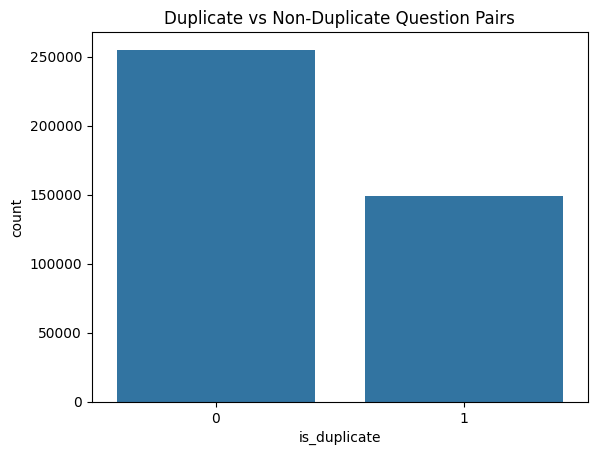

In [11]:
sns.countplot(data=df, x="is_duplicate")
plt.title("Duplicate vs Non-Duplicate Question Pairs")
plt.show()


In [12]:
df["q1_length"] = df["question1"].str.len()
df["q2_length"] = df["question2"].str.len()

In [13]:
df["combined_text"] = df["question1"] + " [SEP] " + df["question2"]

In [14]:
X = df["combined_text"]
y = df["is_duplicate"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [16]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [17]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [18]:
y_pred = model.predict(X_test_tfidf)
y_proba = model.predict_proba(X_test_tfidf)[:, 1]

In [19]:
# Step 11: Evaluation Metrics

# Predictions
y_pred = model.predict(X_test_tfidf)

# Prediction probabilities for ROC-AUC
y_prob = model.predict_proba(X_test_tfidf)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.776901199455917
Precision: 0.7609396388042566
Recall: 0.5771072636549345
F1 Score: 0.6563952159670907
ROC-AUC: 0.8388060114630633

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83     51009
           1       0.76      0.58      0.66     29861

    accuracy                           0.78     80870
   macro avg       0.77      0.74      0.75     80870
weighted avg       0.77      0.78      0.77     80870


Confusion Matrix:
[[45595  5414]
 [12628 17233]]


In [20]:
def predict_duplicate(q1, q2):
    text = q1 + " [SEP] " + q2
    vector = tfidf.transform([text])
    prediction = model.predict(vector)[0]
    probability = model.predict_proba(vector)[0][1]
    return prediction, probability

In [21]:
predict_duplicate(
    "How do I reset my password?",
    "I forgot my password. How can I log in?"
)

(np.int64(1), np.float64(0.6848610869045645))

### The baseline model predicted this pair as duplicate with a probability of 68.49%. This shows that even a simple TF-IDF + Logistic Regression model can identify semantic overlap, but we need a transformer model for stronger contextual understanding.


In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.776901199455917
Precision: 0.7609396388042566
Recall: 0.5771072636549345
F1 Score: 0.6563952159670907
ROC-AUC: 0.8388060114630633

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83     51009
           1       0.76      0.58      0.66     29861

    accuracy                           0.78     80870
   macro avg       0.77      0.74      0.75     80870
weighted avg       0.77      0.78      0.77     80870



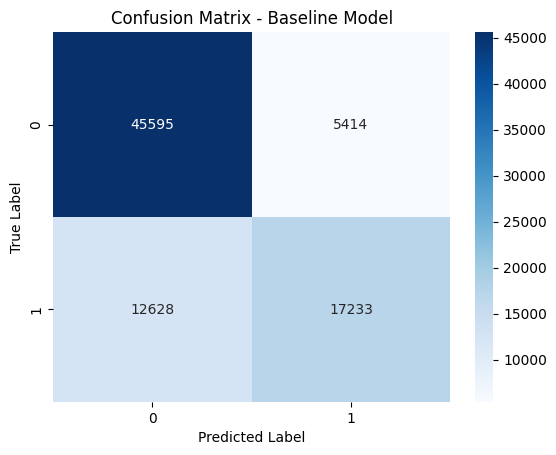

In [23]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Baseline Model")
plt.show()


## Baseline Model Evaluation

The TF-IDF + Logistic Regression baseline achieved an accuracy of 77.69% and ROC-AUC of 83.88%, which shows that lexical similarity features are useful for duplicate-question detection.

However, the recall for duplicate questions is only 57.71%. This means the model misses many true duplicate pairs. In the confusion matrix, 12,628 duplicate question pairs were incorrectly classified as non-duplicates.

For the business use case, this is important because missed duplicates would become unnecessary support tickets instead of being deflected. Therefore, the next step is to train a transformer-based model that can better understand semantic meaning beyond shared words.


True negatives: 45,595

False positives: 5,414

False negatives: 12,628

True positives: 17,233


### Business interpretation:
The model is better at identifying non-duplicates than duplicates. It correctly detects 89% of non-duplicate pairs, but only 58% of duplicate pairs. For a support-ticket deflection system, improving duplicate recall is important because the system should catch as many repeated questions as possible while keeping false deflections controlled.


In [24]:
baseline_results = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression"],
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred)],
    "Recall": [recall_score(y_test, y_pred)],
    "F1 Score": [f1_score(y_test, y_pred)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba)]
})

baseline_results


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,TF-IDF + Logistic Regression,0.776901,0.76094,0.577107,0.656395,0.838806


In [25]:
baseline_results.to_csv("baseline_results.csv", index=False)
